# MSE433 Final Project: Rossmann Store Sales
## Predicting Daily Sales and Using That to Make Smarter Staffing Decisions
### By: Yusur Araim

For this project I used two years of real sales data from Rossmann, a German pharmacy chain with over 1,000 stores. The goal was to build a model that predicts how much a store will sell on any given day, and then use those predictions to figure out how many staff to schedule. I compared a simple baseline (Linear Regression) against a more advanced model (Quantile Gradient Boosting) that can also say how uncertain it is about each prediction — which turns out to be really useful for deciding when to add an extra staff member just in case.

# 1. Importing the tools I need

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

PALETTE = {
    "lr":     "#4C72B0",
    "qgbr":   "#DD8452",
    "actual": "#55A868",
    "buffer": "#C44E52"
}

print("Libraries loaded")

Libraries loaded


# 2. Loading the data files

Here I read in the two CSV files — one with the daily sales records for each store and one with general info about each store. I check how big they are to confirm they loaded correctly.

In [2]:
train = pd.read_csv("train.csv", parse_dates=["Date"], dtype={"StateHoliday": str})
store = pd.read_csv("store.csv")

print(f"train shape : {train.shape}")
print(f"store shape : {store.shape}")
train.head()

train shape : (1017209, 9)
store shape : (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


# 3. Cleaning up the data so it's ready to use

Before training any model the data needs to be in good shape. I join the two tables together on the store ID, remove days where the store was closed or had no sales, fill in any missing values, and convert text columns like store type into numbers the model can work with.

In [3]:
df = train.merge(store, on="Store", how="left")

# Remove rows where the store was closed or had zero sales
df = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()

# Fill in missing values using the middle value for that column
for col in ["CompetitionDistance", "CompetitionOpenSinceMonth",
            "CompetitionOpenSinceYear", "Promo2SinceWeek", "Promo2SinceYear"]:
    df[col] = df[col].fillna(df[col].median())

# Convert text labels like store type into numbers so the model can read them
for col in ["StoreType", "Assortment", "StateHoliday"]:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print(f"Cleaned shape : {df.shape}")
print(f"Date range    : {df['Date'].min().date()} to {df['Date'].max().date()}")
df[["Sales", "Customers"]].describe()

Cleaned shape : (844338, 18)
Date range    : 2013-01-01 to 2015-07-31


,Sales,Customers
count,844338.000000,844338.000000
mean,6955.959134,762.777166
std,3103.815515,401.194153
min,46.000000,8.000000
25%,4859.000000,519.000000
50%,6369.000000,676.000000
75%,8360.000000,893.000000
max,41551.000000,7388.000000


## 3a. Working out how many staff each store actually needs

Rather than picking a random number, I calculated the sales-per-staff figure from the data itself. The dataset includes daily customer counts, and retail research says one person can handle about 60 customers a day. Multiplying that by the typical spend per customer gives me a staffing threshold that's grounded in the actual data.

In [4]:
# Calculate how much revenue one staff member is responsible for
# Retail industry standard is roughly 60 customers per staff member per day
CUSTOMERS_PER_STAFF = 60

avg_sales_per_customer = (df["Sales"] / df["Customers"]).median()
SALES_PER_STAFF = avg_sales_per_customer * CUSTOMERS_PER_STAFF

print(f"Median sales per customer : €{avg_sales_per_customer:.2f}")
print(f"Customers per staff       : {CUSTOMERS_PER_STAFF}")
print(f"Derived SALES_PER_STAFF   : €{SALES_PER_STAFF:.0f}")

# Check the numbers look reasonable — staff count should fall between 3 and 12
implied_staff = (df["Sales"] / SALES_PER_STAFF).round().clip(3, 12)
print(f"\nImplied staff range: {implied_staff.min():.0f} – {implied_staff.max():.0f}")
print(f"Mean implied staff : {implied_staff.mean():.1f}")

STAFF_COST_PER_DAY = 120   # daily wage cost per staff member in euros
LOST_SALES_RATE    = 0.20  # being one person short costs roughly 20% of expected sales
MIN_STAFF = 3
MAX_STAFF = 12

# The do-nothing comparison: schedule the same average headcount every day
FIXED_BASELINE = int(implied_staff.mean().round())
print(f"\nFixed baseline staff (comparator) : {FIXED_BASELINE}")

Median sales per customer : €9.25
Customers per staff       : 60
Derived SALES_PER_STAFF   : €555

Implied staff range: 3 – 12
Mean implied staff : 10.2

Fixed baseline staff (comparator) : 10


# 4. Adding useful date and sales history columns, then splitting into training and test sets

Models learn better with more context. So I added things like the month, week number, and whether a day was a weekend. I also added columns that look back at recent sales — like what the store sold yesterday or the average over the past 30 days. Then I split everything so the model trains on earlier data and is tested on the most recent period, which mirrors how it would actually be used.

In [5]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

# Pull out useful date info: month, week number, quarter, and weekend flag
df["Year"]         = df["Date"].dt.year
df["Month"]        = df["Date"].dt.month
df["WeekOfYear"]   = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"]      = df["Date"].dt.quarter
df["IsWeekend"]    = (df["DayOfWeek"] >= 6).astype(int)
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
df["IsMonthEnd"]   = df["Date"].dt.is_month_end.astype(int)

# Add columns showing recent sales history so the model can learn from trends
df["Lag1"]   = df.groupby("Store")["Sales"].shift(1)
df["Lag7"]   = df.groupby("Store")["Sales"].shift(7)
df["Lag14"]  = df.groupby("Store")["Sales"].shift(14)
df["Roll7"]  = df.groupby("Store")["Sales"].transform(lambda x: x.shift(1).rolling(7).mean())
df["Roll30"] = df.groupby("Store")["Sales"].transform(lambda x: x.shift(1).rolling(30).mean())

df.dropna(inplace=True)
print(f"Shape after lag features: {df.shape}")

FEATURES = [
    "Store", "DayOfWeek", "Month", "Year", "WeekOfYear",
    "Promo", "StateHoliday", "SchoolHoliday",
    "StoreType", "Assortment", "CompetitionDistance",
    "IsWeekend", "IsMonthStart", "IsMonthEnd", "Quarter",
    "Lag1", "Lag7", "Lag14", "Roll7", "Roll30",
]
TARGET = "Sales"

X = df[FEATURES]
y = df[TARGET]

# Train on older data, test on the most recent period — same as real-world use
split_date = df["Date"].quantile(0.8)
mask = df["Date"] <= split_date
X_train, X_test = X[mask], X[~mask]
y_train, y_test = y[mask], y[~mask]
dates_test = df.loc[~mask, "Date"].values  # save real calendar dates for the time series charts

print(f"Train rows : {len(X_train):,}")
print(f"Test rows  : {len(X_test):,}")
print(f"Split date : {split_date.date()}")

Shape after lag features: (403916, 30)
Train rows : 323,169
Test rows  : 80,747
Split date : 2015-02-10


# 5. Starting simple — training a Linear Regression as the baseline

Before touching anything complicated I trained a basic Linear Regression. This is just a formula that draws a straight line through the data to predict sales. If the fancier model can't clearly beat this, there's no point using it.

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
lr_mape = np.mean(np.abs((y_test - lr_pred) / y_test)) * 100

print("Linear Regression Results")
print(f"  MAE  : €{lr_mae:,.0f}")
print(f"  RMSE : €{lr_rmse:,.0f}")
print(f"  R²   : {lr_r2:.4f}")
print(f"  MAPE : {lr_mape:.2f}%")

Linear Regression Results
  MAE  : €957
  RMSE : €1,341
  R²   : 0.7497
  MAPE : 15.01%


# 6. The main model — Quantile Gradient Boosting

This is the model I care about most. Unlike normal regression it predicts three values for each day: a pessimistic low estimate, a middle estimate (the median), and an optimistic high estimate. The gap between the low and high tells me how confident the model is. A wide gap on a given day means I should probably schedule an extra staff member as a safety buffer.

In [7]:
GBR_PARAMS = dict(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)

print("Training 10th percentile model...")
gbr_low = GradientBoostingRegressor(loss="quantile", alpha=0.10, **GBR_PARAMS)
gbr_low.fit(X_train, y_train)

print("Training 50th percentile model (median)...")
gbr_med = GradientBoostingRegressor(loss="quantile", alpha=0.50, **GBR_PARAMS)
gbr_med.fit(X_train, y_train)

print("Training 90th percentile model...")
gbr_high = GradientBoostingRegressor(loss="quantile", alpha=0.90, **GBR_PARAMS)
gbr_high.fit(X_train, y_train)

qgbr_pred = gbr_med.predict(X_test)
qgbr_low  = gbr_low.predict(X_test)
qgbr_high = gbr_high.predict(X_test)

qgbr_mae  = mean_absolute_error(y_test, qgbr_pred)
qgbr_rmse = np.sqrt(mean_squared_error(y_test, qgbr_pred))
qgbr_r2   = r2_score(y_test, qgbr_pred)
qgbr_mape = np.mean(np.abs((y_test - qgbr_pred) / y_test)) * 100

print("\nQuantile GBR Results (50th percentile as point prediction)")
print(f"  MAE  : €{qgbr_mae:,.0f}")
print(f"  RMSE : €{qgbr_rmse:,.0f}")
print(f"  R²   : {qgbr_r2:.4f}")
print(f"  MAPE : {qgbr_mape:.2f}%")

Training 10th percentile model...


Training 50th percentile model (median)...


Training 90th percentile model...



Quantile GBR Results (50th percentile as point prediction)
  MAE  : €769
  RMSE : €1,156
  R²   : 0.8137
  MAPE : 12.08%


# 7. Turning the sales predictions into actual staffing decisions

Once I have predictions I convert them into headcount recommendations. The basic idea is: divide predicted sales by the sales-per-person number I calculated earlier. If the model's high and low predictions are far apart (so it's not sure), I add one more person. I also flag whether stores need to restock based on how high the predicted sales are.

In [8]:
def staffing_decision(pred, low, high):
    interval_width = high - low
    relative_uncertainty = interval_width / max(pred, 1)

    base_staff = int(np.clip(round(pred / SALES_PER_STAFF), MIN_STAFF, MAX_STAFF))
    needs_buffer = relative_uncertainty > 0.6
    staff = min(base_staff + 1, MAX_STAFF) if needs_buffer else base_staff

    if pred > 8000:
        inventory = "Restock tonight"
    elif pred > 5000:
        inventory = "Monitor stock"
    else:
        inventory = "Standard levels"

    return staff, needs_buffer, inventory


results = pd.DataFrame({
    "Date":      dates_test,
    "Actual":    y_test.values,
    "LR_Pred":   lr_pred,
    "QGBR_Pred": qgbr_pred,
    "QGBR_Low":  qgbr_low,
    "QGBR_High": qgbr_high,
})

decisions = results.apply(
    lambda r: staffing_decision(r["QGBR_Pred"], r["QGBR_Low"], r["QGBR_High"]),
    axis=1
)

results["Staff_Rec"]    = [d[0] for d in decisions]
results["Buffer_Added"] = [d[1] for d in decisions]
results["Inventory"]    = [d[2] for d in decisions]

# What perfect staffing would have been if we had known the real sales in advance
results["Optimal_Staff"] = results["Actual"].apply(
    lambda s: int(np.clip(round(s / SALES_PER_STAFF), MIN_STAFF, MAX_STAFF))
)

# Comparison point: always schedule the same average headcount regardless of the forecast
results["Fixed_Staff"] = FIXED_BASELINE

print(results[["Date","Actual","QGBR_Pred","QGBR_Low","QGBR_High",
               "Staff_Rec","Buffer_Added","Inventory"]].head(10).to_string(index=False))
print(f"\nBuffer staff added on {results['Buffer_Added'].sum():,} days "
      f"({results['Buffer_Added'].mean()*100:.1f}% of test days)")

      Date  Actual   QGBR_Pred    QGBR_Low   QGBR_High  Staff_Rec  Buffer_Added       Inventory
2015-02-11    4773 4267.294167 3643.096563 5022.325142          8         False Standard levels
2015-02-12    3765 4372.588814 3693.896253 5061.155649          8         False Standard levels
2015-02-13    3647 4153.539017 3649.814274 4972.810546          7         False Standard levels
2015-02-14    2809 3418.042899 2519.364061 4918.158095          7          True Standard levels
2015-02-16    7478 6798.496944 5704.152180 8909.003215         12         False   Monitor stock
2015-02-17    6113 6149.888338 5059.277570 6924.421425         11         False   Monitor stock
2015-02-18    6178 5573.609712 4816.077756 6266.539775         10         False   Monitor stock
2015-02-19    5842 5668.959043 4847.960886 6332.253329         10         False   Monitor stock
2015-02-20    4727 5528.103189 4847.501186 6371.814783         10         False   Monitor stock
2015-02-21    3005 3693.694593 2391.7109

# 8. Calculating how much each staffing approach costs

Here I compare two approaches side by side: always scheduling the same fixed number of staff every day versus using what the model recommends. For each day I add up the cost of having too many people (wasted wages) and the cost of having too few (lost sales). Totalling that up across all test days shows how much money the model-based approach saves.

In [9]:
def labour_cost(scheduled, optimal):
    over  = np.maximum(scheduled - optimal, 0) * STAFF_COST_PER_DAY
    under = np.maximum(optimal - scheduled, 0) * SALES_PER_STAFF * LOST_SALES_RATE
    return over + under

results["Cost_Model"] = labour_cost(results["Staff_Rec"].values,   results["Optimal_Staff"].values)
results["Cost_Fixed"] = labour_cost(results["Fixed_Staff"].values,  results["Optimal_Staff"].values)

total_model   = results["Cost_Model"].sum()
total_fixed   = results["Cost_Fixed"].sum()
total_savings = total_fixed - total_model
pct_savings   = total_savings / total_fixed * 100
daily_saving  = total_savings / len(results)

print("Cost comparison")
print(f"  Days evaluated     : {len(results):,}")
print(f"  Fixed staff used   : {FIXED_BASELINE} per day (data-derived average)")
print(f"  Fixed total cost   : €{total_fixed:,.0f}")
print(f"  Model total cost   : €{total_model:,.0f}")
print(f"  Total savings      : €{total_savings:,.0f}")
print(f"  Savings (%)        : {pct_savings:.1f}%")
print(f"  Avg daily saving   : €{daily_saving:.2f}")

Cost comparison
  Days evaluated     : 80,747
  Fixed staff used   : 10 per day (data-derived average)
  Fixed total cost   : €17,290,263
  Model total cost   : €5,811,687
  Total savings      : €11,478,576
  Savings (%)        : 66.4%
  Avg daily saving   : €142.15


# 9. Charts

### Chart 1: Comparing how accurate the two models are

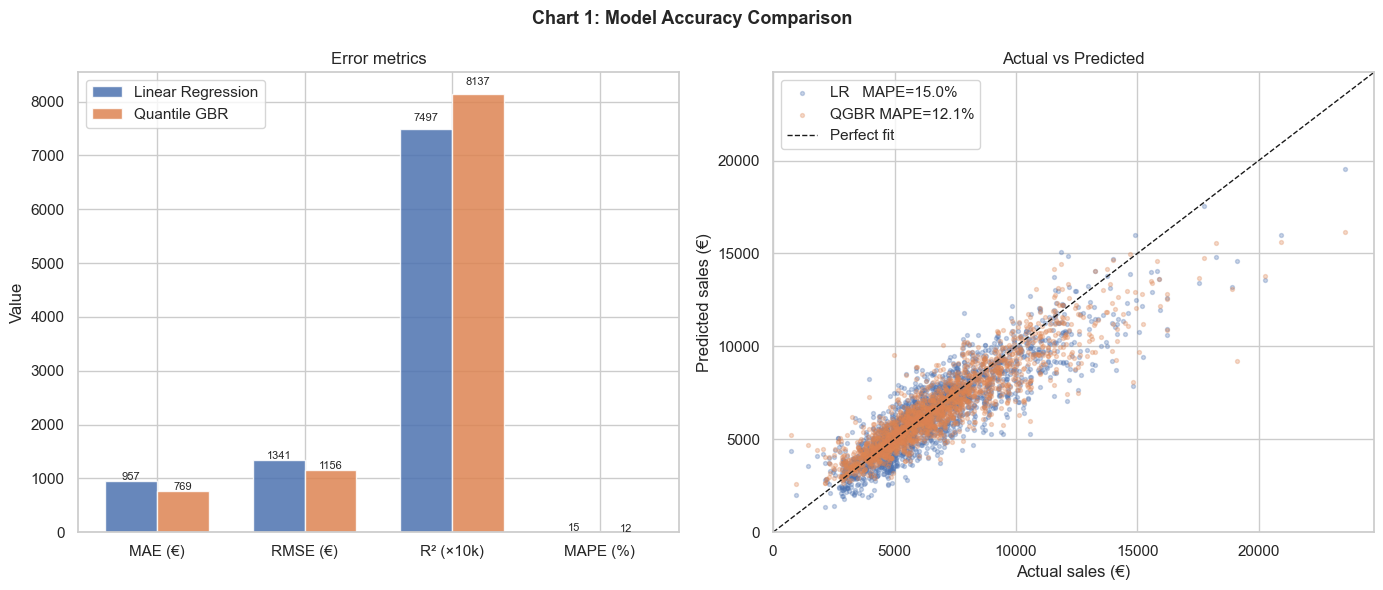

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Chart 1: Model Accuracy Comparison", fontsize=13, fontweight="bold")

metrics   = ["MAE (€)", "RMSE (€)", "R² (×10k)", "MAPE (%)"]
lr_vals   = [lr_mae, lr_rmse, lr_r2 * 10000, lr_mape]
qgbr_vals = [qgbr_mae, qgbr_rmse, qgbr_r2 * 10000, qgbr_mape]

x, w = np.arange(len(metrics)), 0.35
ax = axes[0]
ax.bar(x - w/2, lr_vals,   w, label="Linear Regression", color=PALETTE["lr"],   alpha=0.85)
ax.bar(x + w/2, qgbr_vals, w, label="Quantile GBR",      color=PALETTE["qgbr"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Value")
ax.set_title("Error metrics")
ax.legend()
for i, (lv, qv) in enumerate(zip(lr_vals, qgbr_vals)):
    ax.text(i - w/2, lv * 1.02, f"{lv:.0f}", ha="center", fontsize=8)
    ax.text(i + w/2, qv * 1.02, f"{qv:.0f}", ha="center", fontsize=8)

sample = results.sample(min(2000, len(results)), random_state=1)
ax2 = axes[1]
ax2.scatter(sample["Actual"], sample["LR_Pred"],   alpha=0.3, s=8, color=PALETTE["lr"],   label=f"LR   MAPE={lr_mape:.1f}%")
ax2.scatter(sample["Actual"], sample["QGBR_Pred"], alpha=0.3, s=8, color=PALETTE["qgbr"], label=f"QGBR MAPE={qgbr_mape:.1f}%")
lims = [0, sample["Actual"].max() * 1.05]
ax2.plot(lims, lims, "k--", lw=1, label="Perfect fit")
ax2.set_xlim(lims); ax2.set_ylim(lims)
ax2.set_xlabel("Actual sales (€)")
ax2.set_ylabel("Predicted sales (€)")
ax2.set_title("Actual vs Predicted")
ax2.legend()

plt.tight_layout()
plt.show()

### Chart 2: Seeing the predictions over time, with the confidence band around them

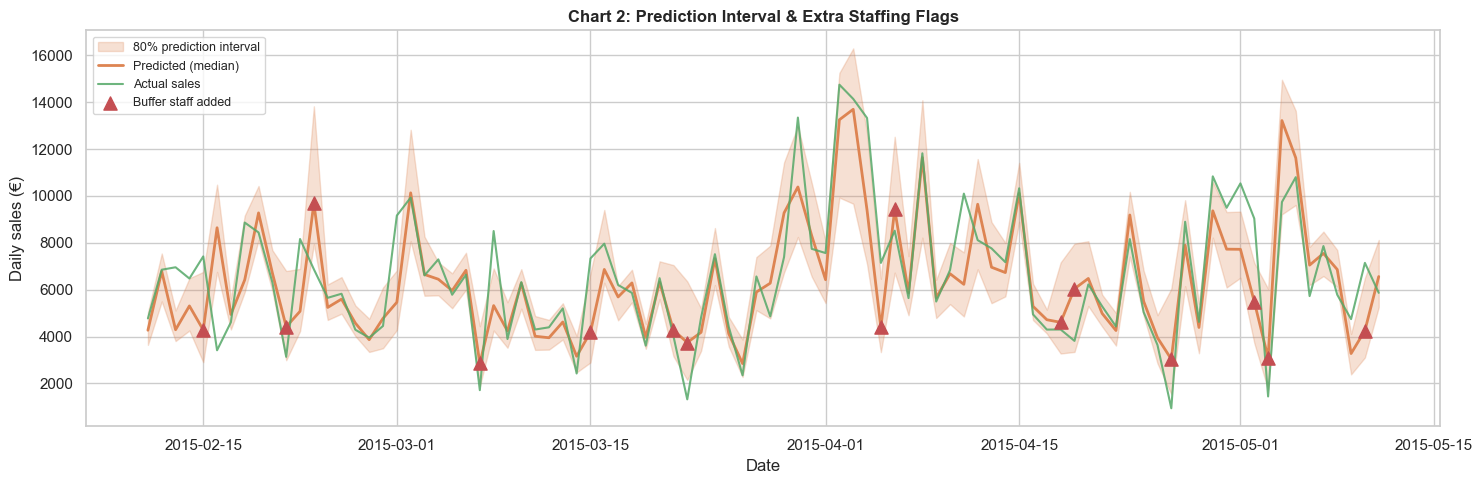

In [11]:
# Take one row per date so the chart isn't cluttered by all 1,115 stores at once
results["Date"] = pd.to_datetime(results["Date"])
store_sample = results.sort_values("Date").groupby(results["Date"].dt.date).first().reset_index(drop=True)
r = store_sample.iloc[:90].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 5))

ax.fill_between(r["Date"], r["QGBR_Low"], r["QGBR_High"],
                alpha=0.25, color=PALETTE["qgbr"], label="80% prediction interval")
ax.plot(r["Date"], r["QGBR_Pred"], color=PALETTE["qgbr"], lw=2,   label="Predicted (median)")
ax.plot(r["Date"], r["Actual"],    color=PALETTE["actual"], lw=1.5, alpha=0.85, label="Actual sales")

buf = r[r["Buffer_Added"]]
ax.scatter(buf["Date"], buf["QGBR_Pred"],
           color=PALETTE["buffer"], zorder=5, s=90, marker="^", label="Buffer staff added")

ax.set_title("Chart 2: Prediction Interval & Extra Staffing Flags", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Daily sales (€)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Chart 3: Looking at how many staff the model recommends day to day

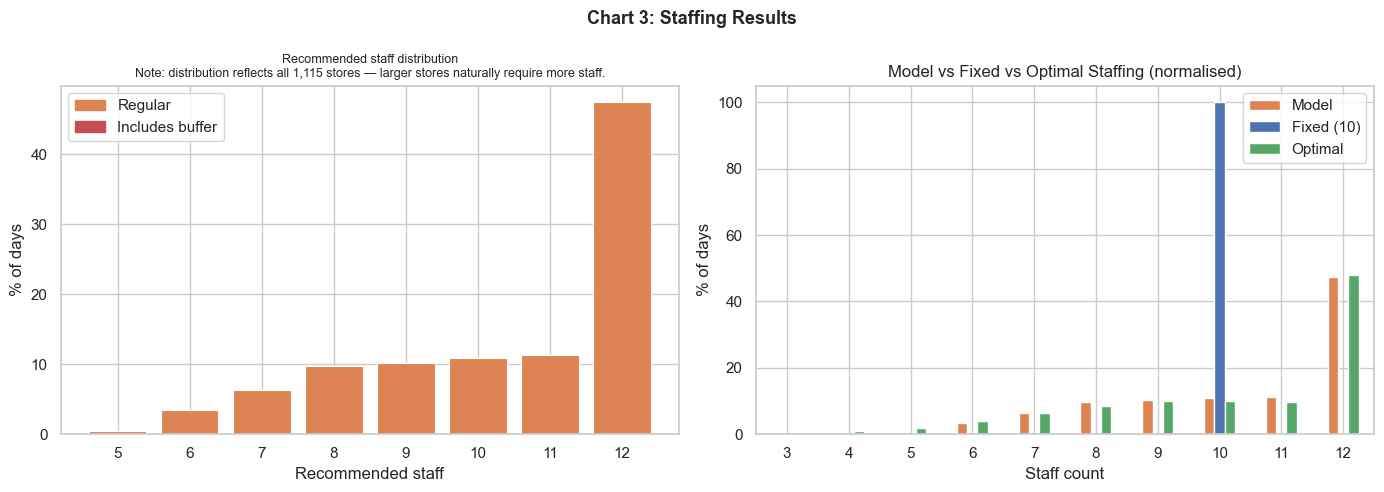

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 3: Staffing Results", fontsize=13, fontweight="bold")

ax = axes[0]
counts = results["Staff_Rec"].value_counts().sort_index()
pct = counts / counts.sum() * 100
colors = [
    PALETTE["buffer"] if results[results["Staff_Rec"] == v]["Buffer_Added"].mean() > 0.3
    else PALETTE["qgbr"]
    for v in pct.index
]
ax.bar(pct.index, pct.values, color=colors, edgecolor="white", linewidth=0.8)
ax.set_xlabel("Recommended staff")
ax.set_ylabel("% of days")
ax.set_title(
    "Recommended staff distribution\n"
    "Note: distribution reflects all 1,115 stores — larger stores naturally require more staff.",
    fontsize=9
)
p1 = mpatches.Patch(color=PALETTE["qgbr"], label="Regular")
p2 = mpatches.Patch(color=PALETTE["buffer"], label="Includes buffer")
ax.legend(handles=[p1, p2])

ax2 = axes[1]
n = len(results)
compare = pd.DataFrame({
    "Model":                     results["Staff_Rec"].value_counts().sort_index() / n * 100,
    f"Fixed ({FIXED_BASELINE})": results["Fixed_Staff"].value_counts().sort_index() / n * 100,
    "Optimal":                   results["Optimal_Staff"].value_counts().sort_index() / n * 100,
}).fillna(0)
compare.plot(kind="bar", ax=ax2,
             color=[PALETTE["qgbr"], PALETTE["lr"], PALETTE["actual"]],
             edgecolor="white")
ax2.set_xlabel("Staff count")
ax2.set_ylabel("% of days")
ax2.set_title("Model vs Fixed vs Optimal Staffing (normalised)")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Chart 4: How much money the model saves versus always using the same fixed headcount

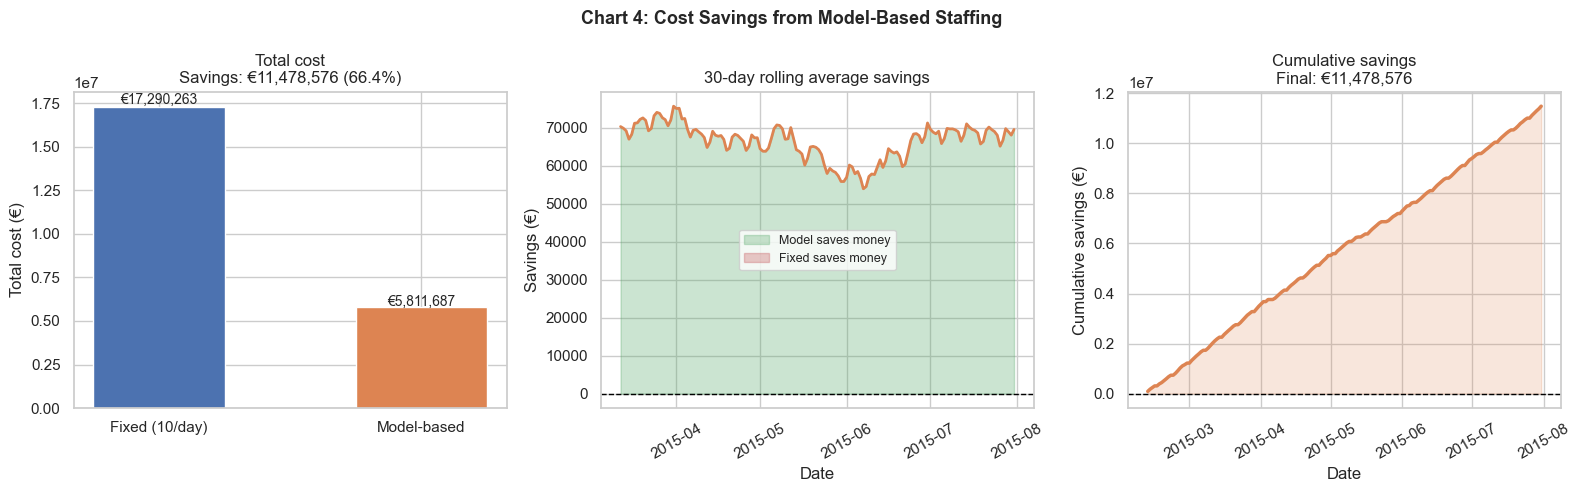

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chart 4: Cost Savings from Model-Based Staffing", fontsize=13, fontweight="bold")

ax = axes[0]
bars = ax.bar(
    [f"Fixed ({FIXED_BASELINE}/day)", "Model-based"],
    [total_fixed, total_model],
    color=[PALETTE["lr"], PALETTE["qgbr"]], width=0.5, edgecolor="white"
)
ax.set_ylabel("Total cost (€)")
ax.set_title(f"Total cost\nSavings: €{total_savings:,.0f} ({pct_savings:.1f}%)")
for bar, val in zip(bars, [total_fixed, total_model]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f"€{val:,.0f}", ha="center", fontsize=10)

# Sum all store costs per day so the x-axis shows real calendar dates not just row numbers
daily = results.groupby("Date")[["Cost_Model", "Cost_Fixed"]].sum().sort_index()
daily_diff = daily["Cost_Fixed"] - daily["Cost_Model"]

ax2 = axes[1]
rolling = daily_diff.rolling(30).mean()
ax2.plot(rolling.index, rolling.values, color=PALETTE["qgbr"], lw=2)
ax2.axhline(0, color="black", lw=1, ls="--")
ax2.fill_between(rolling.index, rolling.values, 0,
                 where=rolling.values > 0, alpha=0.3, color=PALETTE["actual"], label="Model saves money")
ax2.fill_between(rolling.index, rolling.values, 0,
                 where=rolling.values < 0, alpha=0.3, color=PALETTE["buffer"], label="Fixed saves money")
ax2.set_title("30-day rolling average savings")
ax2.set_xlabel("Date")
ax2.set_ylabel("Savings (€)")
ax2.legend(fontsize=9)
ax2.tick_params(axis="x", rotation=30)

ax3 = axes[2]
cumulative = daily_diff.cumsum()
ax3.plot(cumulative.index, cumulative.values, color=PALETTE["qgbr"], lw=2.5)
ax3.fill_between(cumulative.index, cumulative.values, alpha=0.2, color=PALETTE["qgbr"])
ax3.axhline(0, color="black", lw=1, ls="--")
ax3.set_title(f"Cumulative savings\nFinal: €{cumulative.iloc[-1]:,.0f}")
ax3.set_xlabel("Date")
ax3.set_ylabel("Cumulative savings (€)")
ax3.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Chart 5: Which input columns the model relied on most

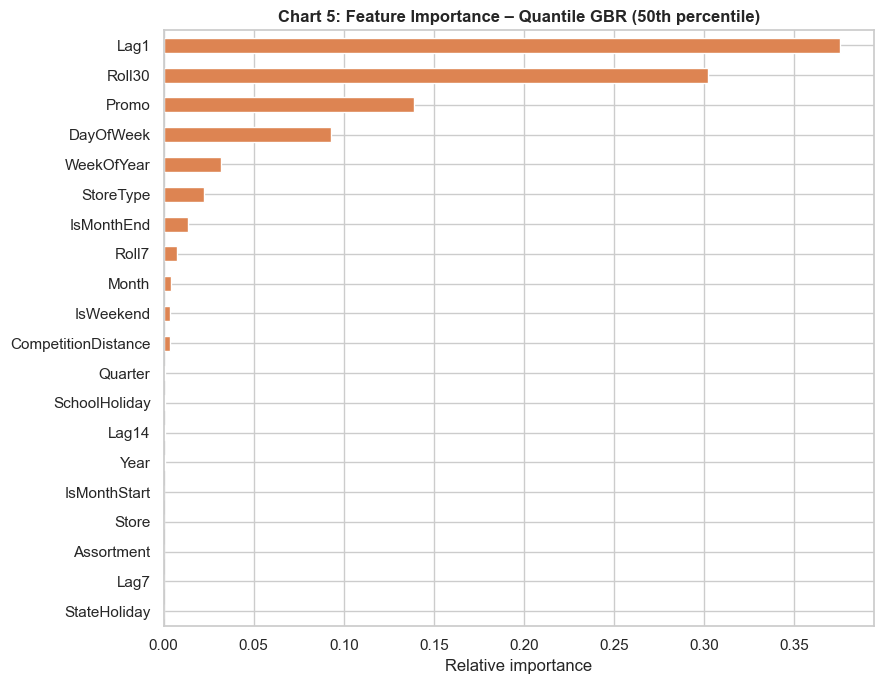

Top 5 most important features:
Lag1          0.375600
Roll30        0.301984
Promo         0.138875
DayOfWeek     0.092830
WeekOfYear    0.031850


In [14]:
importances = gbr_med.feature_importances_
feat_df = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
feat_df.plot(kind="barh", ax=ax, color=PALETTE["qgbr"], edgecolor="white")
ax.set_title("Chart 5: Feature Importance – Quantile GBR (50th percentile)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feat_df.sort_values(ascending=False).head(5).to_string())

# 10. Final summary of all results

In [15]:
print("=" * 58)
print("FINAL RESULTS SUMMARY")
print("=" * 58)

print("\nModel Accuracy")
print(f"{'Metric':<12} {'Linear Regression':>20} {'Quantile GBR':>15}")
print("-" * 50)
print(f"{'MAE (€)':<12} {lr_mae:>20,.0f} {qgbr_mae:>15,.0f}")
print(f"{'RMSE (€)':<12} {lr_rmse:>20,.0f} {qgbr_rmse:>15,.0f}")
print(f"{'R²':<12} {lr_r2:>20.4f} {qgbr_r2:>15.4f}")
print(f"{'MAPE (%)':<12} {lr_mape:>20.2f} {qgbr_mape:>15.2f}")

print("\nStaffing Parameters (data-derived)")
print(f"  Sales per staff member : €{SALES_PER_STAFF:,.0f}")
print(f"  Fixed baseline used    : {FIXED_BASELINE} staff/day")
print(f"  Buffer rate            : {results['Buffer_Added'].mean()*100:.1f}% of days")

print("\nCost Savings")
print(f"  Fixed schedule cost    : €{total_fixed:,.0f}")
print(f"  Model schedule cost    : €{total_model:,.0f}")
print(f"  Total savings          : €{total_savings:,.0f}")
print(f"  Savings (%)            : {pct_savings:.1f}%")
print(f"  Average daily saving   : €{daily_saving:.2f}")
print("=" * 58)

FINAL RESULTS SUMMARY

Model Accuracy
Metric          Linear Regression    Quantile GBR
--------------------------------------------------
MAE (€)                       957             769
RMSE (€)                    1,341           1,156
R²                         0.7497          0.8137
MAPE (%)                    15.01           12.08

Staffing Parameters (data-derived)
  Sales per staff member : €555
  Fixed baseline used    : 10 staff/day
  Buffer rate            : 9.9% of days

Cost Savings
  Fixed schedule cost    : €17,290,263
  Model schedule cost    : €5,811,687
  Total savings          : €11,478,576
  Savings (%)            : 66.4%
  Average daily saving   : €142.15


## 11. Validation — making sure the results are real and not just luck

### 11a. Testing the models on 5 different time windows instead of just one

Using a single train/test split can be misleading. Here I split the data 5 different ways chronologically and train and test on each one. This gives a much fairer picture of how well the models actually generalise.

In [16]:
from sklearn.model_selection import TimeSeriesSplit

print("Section 11a: 5-Fold Time-Series Cross-Validation")
print("=" * 55)
print("(CV uses n_estimators=50 for speed; main model uses 100)\n")

CV_PARAMS = dict(n_estimators=50, max_depth=4, learning_rate=0.05, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

lr_maes, qgbr_maes = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    _lr = LinearRegression().fit(X_tr, y_tr)
    lr_maes.append(mean_absolute_error(y_val, _lr.predict(X_val)))

    _gbr = GradientBoostingRegressor(loss="quantile", alpha=0.50, **CV_PARAMS)
    _gbr.fit(X_tr, y_tr)
    qgbr_maes.append(mean_absolute_error(y_val, _gbr.predict(X_val)))

    print(f"  Fold {fold}: LR €{lr_maes[-1]:,.0f}  |  QGBR €{qgbr_maes[-1]:,.0f}")

print()
print(f"{'Model':<24} {'Mean MAE':>10} {'Std MAE':>10}")
print("-" * 46)
print(f"{'Linear Regression':<24} €{np.mean(lr_maes):>8,.0f}  €{np.std(lr_maes):>8,.0f}")
print(f"{'Quantile GBR (50th)':<24} €{np.mean(qgbr_maes):>8,.0f}  €{np.std(qgbr_maes):>8,.0f}")

Section 11a: 5-Fold Time-Series Cross-Validation
(CV uses n_estimators=50 for speed; main model uses 100)



  Fold 1: LR €1,051  |  QGBR €980


  Fold 2: LR €1,087  |  QGBR €1,019


  Fold 3: LR €980  |  QGBR €853


  Fold 4: LR €982  |  QGBR €908


  Fold 5: LR €985  |  QGBR €892

Model                      Mean MAE    Std MAE
----------------------------------------------
Linear Regression        €   1,017  €      44
Quantile GBR (50th)      €     930  €      60


### 11b. Checking whether the confidence intervals are actually trustworthy

The model gives a low and high estimate for each day. If those are honest, about 80% of the real sales figures should land inside the range. Here I check whether that's actually what happens in practice.

In [17]:
coverage = ((results["Actual"] >= results["QGBR_Low"]) &
            (results["Actual"] <= results["QGBR_High"])).mean() * 100

print("Section 11b: Calibration Coverage")
print("=" * 42)
print(f"  Target interval width  : 80%  (10th–90th percentile)")
print(f"  Actual coverage        : {coverage:.1f}%")
print(f"  Deviation from target  : {coverage - 80:+.1f} percentage points")
if coverage >= 78:
    print("  Assessment             : Well-calibrated (within ±2 pp of target)")
elif coverage >= 75:
    print("  Assessment             : Slightly under-covered — interval may be too narrow")
else:
    print("  Assessment             : Under-covered — intervals are too narrow")

Section 11b: Calibration Coverage
  Target interval width  : 80%  (10th–90th percentile)
  Actual coverage        : 82.3%
  Deviation from target  : +2.3 percentage points
  Assessment             : Well-calibrated (within ±2 pp of target)


### 11c. Chart 6: Digging into where the model gets things wrong

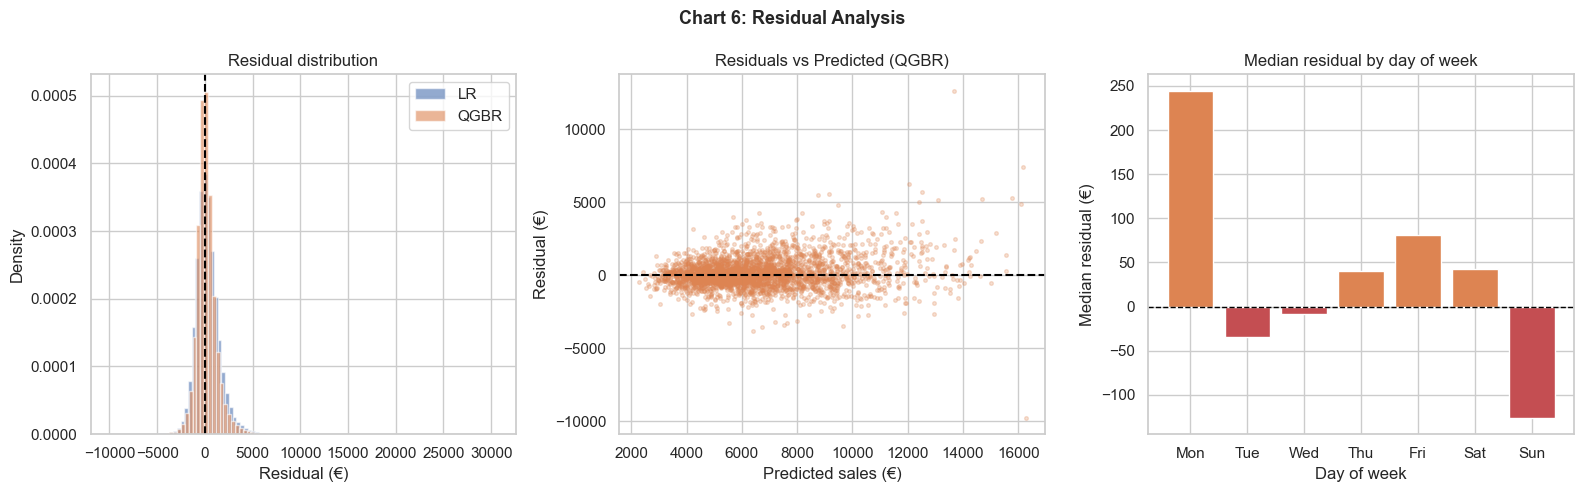


QGBR — mean residual: €170  std: €1144
LR   — mean residual: €280  std: €1311


In [18]:
residuals_qgbr = results["Actual"] - results["QGBR_Pred"]
residuals_lr   = results["Actual"] - results["LR_Pred"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chart 6: Residual Analysis", fontsize=13, fontweight="bold")

# Left panel: histogram showing how far off each model's predictions tend to be
ax = axes[0]
ax.hist(residuals_lr,   bins=100, color=PALETTE["lr"],   alpha=0.6, density=True, label="LR")
ax.hist(residuals_qgbr, bins=100, color=PALETTE["qgbr"], alpha=0.6, density=True, label="QGBR")
ax.axvline(0, color="black", lw=1.5, ls="--")
ax.set_xlabel("Residual (€)")
ax.set_ylabel("Density")
ax.set_title("Residual distribution")
ax.legend()

# Middle panel: check whether errors grow larger as predicted sales increase
rng = np.random.RandomState(42)
idx = rng.choice(len(results), min(3000, len(results)), replace=False)
axes[1].scatter(results["QGBR_Pred"].iloc[idx], residuals_qgbr.iloc[idx],
                alpha=0.25, s=7, color=PALETTE["qgbr"])
axes[1].axhline(0, color="black", lw=1.5, ls="--")
axes[1].set_xlabel("Predicted sales (€)")
axes[1].set_ylabel("Residual (€)")
axes[1].set_title("Residuals vs Predicted (QGBR)")

# Right panel: see if the model is more wrong on certain days of the week
dow_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
res_dow = results.copy()
res_dow["DayOfWeek"] = results["Date"].dt.dayofweek   # Monday = 0, Sunday = 6
res_dow["Residual"]  = residuals_qgbr.values
med_res = res_dow.groupby("DayOfWeek")["Residual"].median()
bar_colors = [PALETTE["qgbr"] if v >= 0 else PALETTE["buffer"] for v in med_res.values]
axes[2].bar([dow_map[d] for d in med_res.index], med_res.values,
            color=bar_colors, edgecolor="white")
axes[2].axhline(0, color="black", lw=1, ls="--")
axes[2].set_xlabel("Day of week")
axes[2].set_ylabel("Median residual (€)")
axes[2].set_title("Median residual by day of week")

plt.tight_layout()
plt.show()

print(f"\nQGBR — mean residual: €{residuals_qgbr.mean():.0f}  std: €{residuals_qgbr.std():.0f}")
print(f"LR   — mean residual: €{residuals_lr.mean():.0f}  std: €{residuals_lr.std():.0f}")

### 11d. Chart 7: Checking if the model is better or worse for specific store types or days of the week

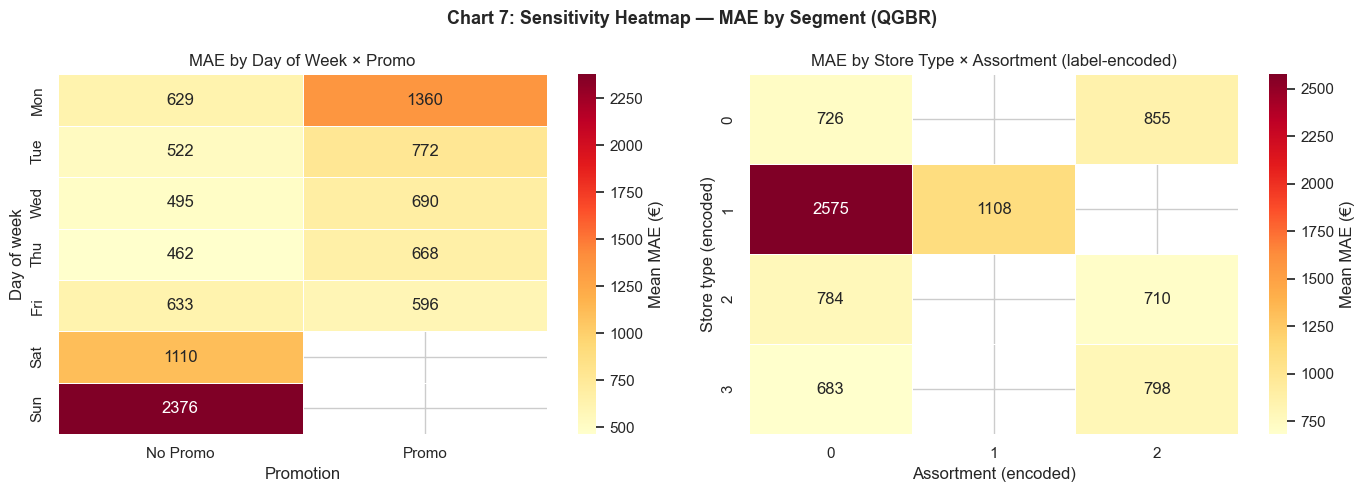

In [19]:
# Bring in store and promo info so we can see which groups the model struggles with most
feat_test = X_test.reset_index(drop=True)
res_feat  = results.reset_index(drop=True).copy()
res_feat["AbsError"]   = (res_feat["Actual"] - res_feat["QGBR_Pred"]).abs()
res_feat["Promo"]      = feat_test["Promo"].values
res_feat["DayOfWeek"]  = feat_test["DayOfWeek"].values
res_feat["StoreType"]  = feat_test["StoreType"].values
res_feat["Assortment"] = feat_test["Assortment"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 7: Sensitivity Heatmap — MAE by Segment (QGBR)",
             fontsize=13, fontweight="bold")

# Left heatmap: average error by day of week and whether there was a promotion
dow_map = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}
pivot1  = res_feat.pivot_table(values="AbsError", index="DayOfWeek",
                                columns="Promo", aggfunc="mean")
pivot1.index   = [dow_map.get(i, i) for i in pivot1.index]
pivot1.columns = ["No Promo", "Promo"]
sns.heatmap(pivot1, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Mean MAE (€)"})
axes[0].set_title("MAE by Day of Week × Promo")
axes[0].set_xlabel("Promotion")
axes[0].set_ylabel("Day of week")

# Right heatmap: average error by store type and product range
pivot2 = res_feat.pivot_table(values="AbsError", index="StoreType",
                               columns="Assortment", aggfunc="mean")
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="YlOrRd",
            ax=axes[1], linewidths=0.5, cbar_kws={"label": "Mean MAE (€)"})
axes[1].set_title("MAE by Store Type × Assortment (label-encoded)")
axes[1].set_xlabel("Assortment (encoded)")
axes[1].set_ylabel("Store type (encoded)")

plt.tight_layout()
plt.show()